In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-book-foundations.6j_z9po4/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-book-foundations.6j_z9po4/venv", "python": "3.12.14", "torch_cuda_build": null}


# Session 03 — How One-Hot Targets Become a Distribution

Every training row names one observed token. This notebook makes visible how repeated one-hot corrections can nevertheless teach a calibrated non-one-hot next-token distribution.

**Learning cycle:** deep question → prediction → transparent gradient → optimizer trajectory → perturbation → evidence boundary.

## 0. Load the reusable experiment

The reusable computation lives in `src/dongxi_llms/next_token_distribution_lab.py`; this notebook narrates it and exposes its intermediate quantities.

In [2]:
import math
import sys
from pathlib import Path

import torch

repo_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / 'src' / 'dongxi_llms').is_dir()
)
sys.path.insert(0, str(repo_root / 'src'))

from dongxi_llms.next_token_distribution_lab import run_experiment

print('Repository:', repo_root)
print('PyTorch:', torch.__version__)

Repository: /home/dongxi/dongxi_ai/Dongxi_LLMs
PyTorch: 2.14.1+cpu


### Prediction

## 1. The apparent paradox

For one fixed context, the dataset contains 70 `dog` targets and 30 `cat` targets. Every individual target is one-hot. Before continuing, explain qualitatively why the model should not converge to 100% `dog`.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Prediction

## 2. Implement the per-example logit gradient

For probabilities $p$ and one-hot target $q$, implement $\partial L/\partial z=p-q$.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


In [3]:
def logit_gradient(probabilities, one_hot_target):
    # Replace ... after stating what each sign should mean.
    return ...

### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [4]:
def reference_logit_gradient(probabilities, one_hot_target):
    return probabilities - one_hot_target

p = torch.tensor([0.7, 0.3])
q_dog = torch.tensor([1.0, 0.0])
q_cat = torch.tensor([0.0, 1.0])
g_dog = reference_logit_gradient(p, q_dog)
g_cat = reference_logit_gradient(p, q_cat)
print('dog-example gradient:', g_dog.tolist())
print('cat-example gradient:', g_cat.tolist())
assert torch.allclose(g_dog, torch.tensor([-0.3, 0.3]))
assert torch.allclose(g_cat, torch.tensor([0.7, -0.7]))

dog-example gradient: [-0.30000001192092896, 0.30000001192092896]
cat-example gradient: [0.699999988079071, -0.699999988079071]


### Reference explanation

<details>
<summary><strong>Reference explanation</strong></summary>

A `dog` example pulls probability toward `dog`, but each `cat` example pulls it back toward `cat`. Assigning zero probability to `cat` would make every observed `cat` infinitely surprising in exact mathematics. Across representative repetitions, the pulls balance at their frequencies—not at the modal token alone.
</details>

**Why the signs matter:** gradient descent moves opposite the gradient. A `dog` example raises the `dog` logit and lowers `cat`; a `cat` example does the reverse. Neither example states the complete distribution by itself.


### Prediction

## 3. Show how competing one-hot gradients balance

At $p=[0.7,0.3]$, combine the two per-example gradients using the observed 70/30 frequencies. Predict whether the result should point toward `dog`, toward `cat`, or nowhere.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


In [5]:
def expected_gradient(dog_frequency, dog_gradient, cat_gradient):
    # Replace ... with the frequency-weighted gradient.
    return ...

### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [6]:
def reference_expected_gradient(dog_frequency, dog_gradient, cat_gradient):
    return dog_frequency * dog_gradient + (1 - dog_frequency) * cat_gradient

g_expected = reference_expected_gradient(0.7, g_dog, g_cat)
print('expected gradient:', g_expected.tolist())
assert torch.allclose(g_expected, torch.zeros(2), atol=1e-7)

expected gradient: [0.0, 0.0]


### Reference explanation

**Mechanism:** $\mathbb{E}[q]=r$, so $\mathbb{E}[p-q]=p-r$. At $p=r$, individual examples still disagree, but their expected corrections cancel. With small random minibatches, gradients fluctuate around this equilibrium rather than remaining exactly zero.


### Prediction

## 4. Watch two logits learn 70/30

The model has no transformer and no semantic features—only two shared trainable logits. This isolates the optimization mechanism. Predict what should happen to probability, loss, and gradient norm.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [7]:
result = run_experiment(steps=500, learning_rate=0.5, seed=42)
print(f"{'step':>5}  {'p(dog)':>10}  {'p(cat)':>10}  {'loss':>10}  {'|grad|':>12}")
for row in result['checkpoints']:
    p_dog, p_cat = row['probabilities']
    print(
        f"{row['step']:5d}  {p_dog:10.7f}  {p_cat:10.7f}  "
        f"{row['mean_cross_entropy']:10.7f}  {row['gradient_norm']:12.3e}"
    )
assert result['all_criteria_passed']

 step      p(dog)      p(cat)        loss        |grad|
    0   0.5000000   0.5000000   0.6931473     2.828e-01
    1   0.5498340   0.4501660   0.6581388     2.124e-01
    2   0.5866578   0.4133422   0.6383634     1.603e-01
    5   0.6492183   0.3507817   0.6166678     7.182e-02
   10   0.6854001   0.3145998   0.6113629     2.065e-02
   50   0.6999989   0.3000011   0.6108643     1.581e-06
  100   0.7000000   0.3000000   0.6108643     7.451e-09
  500   0.7000000   0.3000000   0.6108643     7.451e-09


### Reference explanation

**What converged:** the prediction approaches `[0.7,0.3]`, loss approaches the empirical entropy, and the full-batch gradient approaches zero. The nonzero limiting loss is successful calibrated learning, not residual optimizer failure.


### Prediction

## 5. Recover the learned logit gap

Softmax implies $p_0/p_1=\exp(z_0-z_1)$. Implement the logit difference required by a two-class target distribution.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


In [8]:
def required_logit_gap(probability_0, probability_1):
    return ...

### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [9]:
def reference_required_logit_gap(probability_0, probability_1):
    return math.log(probability_0 / probability_1)

expected_gap = reference_required_logit_gap(0.7, 0.3)
final_logits = result['checkpoints'][-1]['logits']
observed_gap = final_logits[0] - final_logits[1]
print('expected gap:', expected_gap)
print('observed gap:', observed_gap)
assert math.isclose(observed_gap, expected_gap, abs_tol=1e-6)

expected gap: 0.8472978603872037
observed gap: 0.847297728061676


### Reference explanation

**Why only the gap is learned:** adding the same constant to both logits changes neither their ratio nor softmax. The experiment's symmetric values near `[0.42365,-0.42365]` are one representative of an infinite family with the same difference.


### Prediction

## 6. Perturb the final distribution

Compare expected cross-entropy for an underconfident prediction, the calibrated prediction, and a mode-seeking prediction. Which should have minimum expected loss?

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [10]:
target_distribution = torch.tensor([0.7, 0.3])
candidate_predictions = {
    'underconfident': torch.tensor([0.5, 0.5]),
    'calibrated': torch.tensor([0.7, 0.3]),
    'mode-seeking': torch.tensor([0.9, 0.1]),
}
losses = {}
for name, prediction in candidate_predictions.items():
    losses[name] = -(target_distribution * torch.log(prediction)).sum().item()
    print(f'{name:14s}: {losses[name]:.7f}')
assert min(losses, key=losses.get) == 'calibrated'

underconfident: 0.6931472
calibrated    : 0.6108643
mode-seeking  : 0.7645280


### Reference explanation

**Interpretation:** expected cross-entropy is minimized at the complete target distribution, not at the most frequent outcome alone. In $H(r,p)=H(r)+D_{KL}(r\|p)$, changing the model can remove KL mismatch but cannot remove target entropy.


### Prediction

## 7. Evidence boundary

Write one sentence for each: what did this experiment demonstrate, and what would be an unsupported claim about real language models?

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Prediction

## Final synthesis question

At convergence, every individual one-hot example can still have a nonzero gradient and the mean loss can remain positive. Explain why the full-batch expected gradient is nevertheless zero—and why this is successful learning rather than a contradiction.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


## Visual extension — residual uncertainty at successful convergence


### Prediction

Prediction: Will the loss vanish when p matches the 70/30 target frequencies? What should happen to the gradient?

Make your explanation before running the plot.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


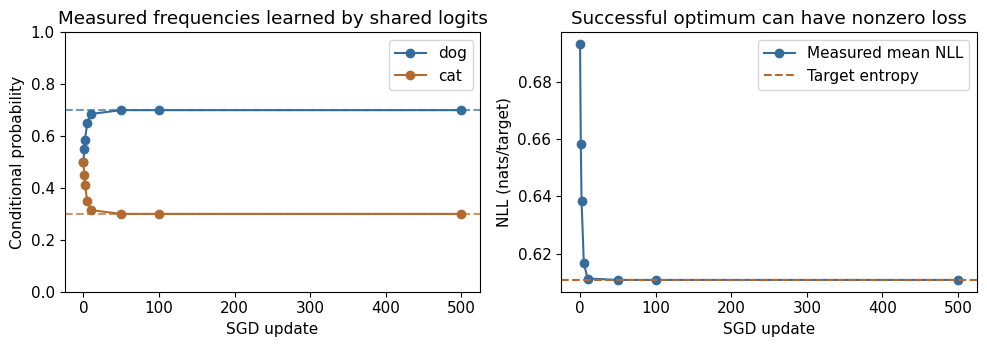

In [11]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white",
                     "font.family":"DejaVu Sans","font.size":11})
visual_rows=result["checkpoints"]
visual_steps=[r["step"] for r in visual_rows]
visual_prob=np.array([r["probabilities"] for r in visual_rows])
visual_entropy=-(.7*math.log(.7)+.3*math.log(.3))
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
for index,name,color,target in [(0,"dog","#346c9c",.7),(1,"cat","#b16b31",.3)]:
    axes[0].plot(visual_steps,visual_prob[:,index],"o-",label=name,color=color)
    axes[0].axhline(target,color=color,linestyle="--",alpha=.7)
axes[0].set(xlabel="SGD update",ylabel="Conditional probability",ylim=(0,1),title="Measured frequencies learned by shared logits"); axes[0].legend()
axes[1].plot(visual_steps,[r["mean_cross_entropy"] for r in visual_rows],"o-",color="#346c9c",label="Measured mean NLL")
axes[1].axhline(visual_entropy,color="#b16b31",linestyle="--",label="Target entropy")
axes[1].set(xlabel="SGD update",ylabel="NLL (nats/target)",title="Successful optimum can have nonzero loss")
axes[1].legend(); plt.tight_layout(); plt.show()
assert abs(visual_rows[-1]["mean_cross_entropy"]-visual_entropy)<1e-6

### Reference explanation

<details>
<summary><strong>Reference boundary</strong></summary>

**Supported:** in this controlled two-logit, full-batch system, repeated 70/30 one-hot targets made PyTorch cross-entropy converge to the empirical distribution, and autograd agreed with `p-r`.

**Not supported:** this does not establish that a transformer recovers the true human-language distribution, generalizes to unseen contexts, understands either token, or remains calibrated under dataset and decoding shift.
</details>

<details>
<summary><strong>Reference synthesis</strong></summary>

A `dog` sample pulls toward `dog` and a `cat` sample pulls toward `cat`; at `p=r`, their frequency-weighted gradients cancel because $\mathbb{E}[p-q]=p-r=0$. The positive loss equals the uncertainty $H(r)$ that remains even after KL mismatch vanishes. Zero expected gradient says no local change can improve expected cross-entropy under this empirical distribution; it does not say every sampled outcome became certain.
</details>

### Reference explanation and reading guide

The left panel follows measured probability checkpoints toward the empirical distribution. The right panel shows mean NLL approaching the target entropy. The nonzero entropy reflects genuine uncertainty in this two-outcome fixture; a small gradient at that loss is expected convergence, not automatically optimizer failure.

Saved reference preview (generated 2026-10-04):

![Visual extension — residual uncertainty at successful convergence](../figures/chapter-03/day-03-03_distribution_learning-01.png)

The preview is fixed; rerun the reference cell above to regenerate figures from the current reference tensors. Matplotlib is required for this optional visual extension.
